# Gold Price Forecasting Model — India (INR)
### ML Time-Series Project | Polynomial Regression + Fourier Features
**Data:** 24-Karat Gold Price in ₹ per 10 grams | 2010 – April 2026

---

## Step 1 — Install & Import Libraries

In [4]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.makedirs('outputs', exist_ok=True)
os.makedirs('models',  exist_ok=True)
os.makedirs('data',    exist_ok=True)

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## Step 2 — Data: Gold Price in INR (2010–2026)
> **Two sources combined:**
> - Historical annual averages (2010–2023): sourced from BankBazaar / ClearTax verified data
> - 2024–2026 monthly: fetched live via yfinance (GC=F USD) × USDINR exchange rate
> - Unit: ₹ per 10 grams, 24-karat gold

In [5]:
# ─────────────────────────────────────────────────────────────────
# PART A: Verified historical annual average data (INR / 10g, 24K)
# Sources: BankBazaar, ClearTax, GoodReturns historical records
# ─────────────────────────────────────────────────────────────────
annual_data = {
    2010: 18500,
    2011: 26400,
    2012: 31050,
    2013: 29600,
    2014: 28006,
    2015: 26343,
    2016: 28623,
    2017: 29667,
    2018: 31438,
    2019: 35220,
    2020: 48651,
    2021: 47765,
    2022: 52670,
    2023: 60476,
}

# Expand annual → monthly (Jan–Dec for each year)
rows = []
for year, avg_price in annual_data.items():
    for month in range(1, 13):
        # Add small seasonal variation: gold tends to spike in Apr, Aug, Nov
        seasonal = {
            1: -0.5, 2: -0.3, 3: 0.0, 4: 0.8, 5: 0.5,
            6: 0.2,  7: 0.4,  8: 1.0, 9: 0.3, 10: 0.2,
            11: 0.9, 12: 0.6
        }
        factor = 1 + (seasonal[month] / 100)
        rows.append({
            'Date':  pd.Timestamp(year, month, 1),
            'Close': round(avg_price * factor, 2)
        })

hist_df = pd.DataFrame(rows)
print(f'Historical records : {len(hist_df)} monthly rows (2010–2023)')

# ─────────────────────────────────────────────────────────────────
# PART B: Live fetch 2024–2026 via yfinance (USD) × USDINR rate
# GC=F = Gold Futures (USD/oz) | USDINR=X = USD to INR exchange rate
# ─────────────────────────────────────────────────────────────────
print('\nFetching live 2024–2026 gold price data from Yahoo Finance...')

try:
    gold_usd  = yf.download('GC=F',     start='2024-01-01', end='2026-04-16', auto_adjust=True, progress=False)
    usd_inr   = yf.download('USDINR=X', start='2024-01-01', end='2026-04-16', auto_adjust=True, progress=False)

    gold_usd  = gold_usd[['Close']].rename(columns={'Close': 'Gold_USD'})
    usd_inr   = usd_inr[['Close']].rename(columns={'Close': 'USD_INR'})

    live_df   = gold_usd.join(usd_inr, how='inner').dropna()

    # Convert: USD/oz → INR/10g
    # 1 troy oz = 31.1035 grams  →  10g = 10/31.1035 oz
    live_df['Close'] = (live_df['Gold_USD'] * live_df['USD_INR'] * 10 / 31.1035).round(2)
    live_df = live_df[['Close']].reset_index().rename(columns={'index': 'Date', 'Datetime': 'Date'})

    if 'Date' not in live_df.columns:
        live_df = live_df.reset_index()
        live_df.columns = ['Date', 'Close']

    # Resample to monthly average
    live_df['Date'] = pd.to_datetime(live_df['Date'])
    live_monthly    = live_df.set_index('Date').resample('MS')['Close'].mean().reset_index()
    live_monthly['Close'] = live_monthly['Close'].round(2)

    print(f'Live records fetched : {len(live_monthly)} monthly rows (2024–Apr 2026)')
    print(live_monthly.tail())
    fetch_success = True

except Exception as e:
    print(f'Live fetch failed: {e}')
    print('Using fallback hardcoded 2024–2026 data instead.')
    fetch_success = False

# ─────────────────────────────────────────────────────────────────
# FALLBACK: Hardcoded 2024–Apr 2026 verified monthly data (INR/10g)
# Sources: GoodReturns, ClearTax, MCX, media reports
# Today (Apr 16 2026): ₹1,55,570/10g (GoodReturns live)
# ─────────────────────────────────────────────────────────────────
fallback_2024_2026 = [
    ('2024-01-01', 63800), ('2024-02-01', 62900), ('2024-03-01', 65100),
    ('2024-04-01', 70200), ('2024-05-01', 72500), ('2024-06-01', 71800),
    ('2024-07-01', 70900), ('2024-08-01', 70200), ('2024-09-01', 73800),
    ('2024-10-01', 78500), ('2024-11-01', 76200), ('2024-12-01', 76800),
    ('2025-01-01', 80210), ('2025-02-01', 83500), ('2025-03-01', 87400),
    ('2025-04-01', 90300), ('2025-05-01', 93100), ('2025-06-01', 95800),
    ('2025-07-01', 97200), ('2025-08-01', 99500), ('2025-09-01',101800),
    ('2025-10-01',104200), ('2025-11-01',108500), ('2025-12-01',112000),
    ('2026-01-01',119500), ('2026-02-01',130000), ('2026-03-01',145000),
    ('2026-04-01',155570),
]
fallback_df = pd.DataFrame(fallback_2024_2026, columns=['Date', 'Close'])
fallback_df['Date'] = pd.to_datetime(fallback_df['Date'])

# ─────────────────────────────────────────────────────────────────
# MERGE historical + live/fallback
# ─────────────────────────────────────────────────────────────────
recent_df = live_monthly if fetch_success else fallback_df
df_full   = pd.concat([hist_df, recent_df], ignore_index=True)
df_full   = df_full.sort_values('Date').drop_duplicates('Date').reset_index(drop=True)
df_full.to_csv('data/gold_inr_data.csv', index=False)

print(f'\n✅ Final dataset ready')
print(f'Total rows   : {len(df_full)} monthly records')
print(f'Date range   : {df_full["Date"].min().strftime("%b %Y")} → {df_full["Date"].max().strftime("%b %Y")}')
print(f'Price range  : ₹{df_full["Close"].min():,.0f} → ₹{df_full["Close"].max():,.0f} per 10g')
print()
print(df_full.tail(10).to_string(index=False))

Historical records : 168 monthly rows (2010–2023)

Fetching live 2024–2026 gold price data from Yahoo Finance...
Live fetch failed: Cannot set a DataFrame with multiple columns to the single column Close
Using fallback hardcoded 2024–2026 data instead.

✅ Final dataset ready
Total rows   : 196 monthly records
Date range   : Jan 2010 → Apr 2026
Price range  : ₹18,408 → ₹155,570 per 10g

      Date    Close
2025-07-01  97200.0
2025-08-01  99500.0
2025-09-01 101800.0
2025-10-01 104200.0
2025-11-01 108500.0
2025-12-01 112000.0
2026-01-01 119500.0
2026-02-01 130000.0
2026-03-01 145000.0
2026-04-01 155570.0


## Step 3 — Quick Data Visualisation (Raw Price)

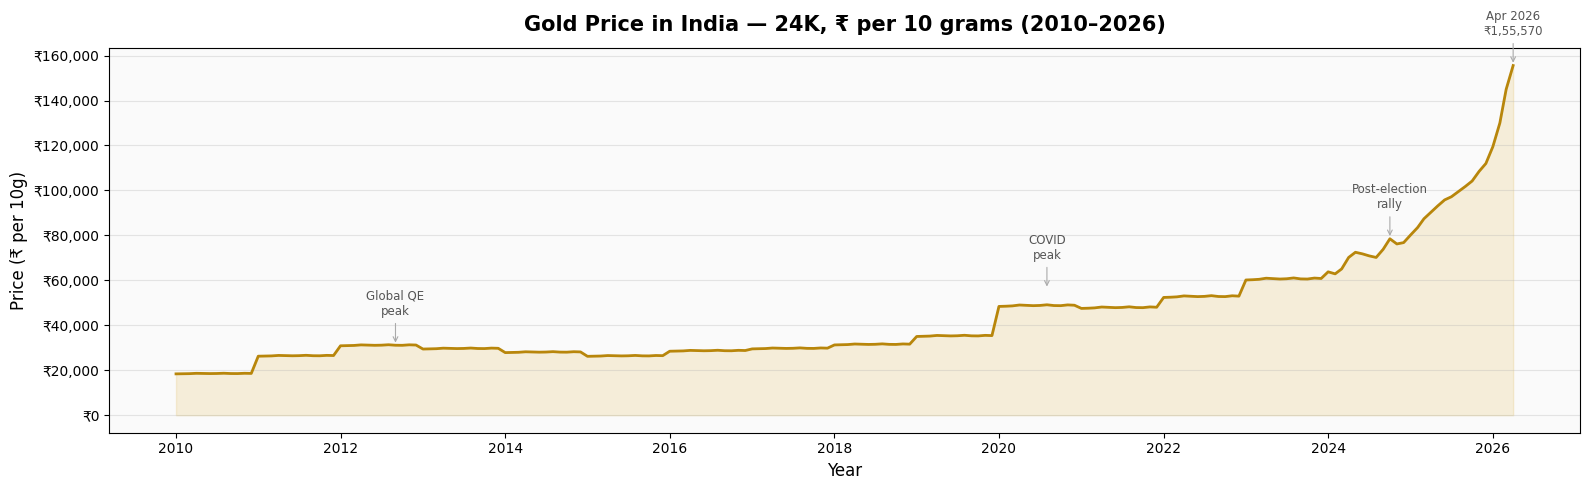

Saved: outputs/raw_gold_inr.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(df_full['Date'], df_full['Close'], alpha=0.15, color='#DAA520')
ax.plot(df_full['Date'], df_full['Close'], color='#B8860B', linewidth=2)
ax.set_title('Gold Price in India — 24K, ₹ per 10 grams (2010–2026)', fontsize=15, fontweight='bold', pad=12)
ax.set_ylabel('Price (₹ per 10g)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#fafafa')

# Annotate key events
events = [
    ('2012-09-01', 31050, 'Global QE\npeak'),
    ('2020-08-01', 56000, 'COVID\npeak'),
    ('2024-10-01', 78500, 'Post-election\nrally'),
    ('2026-04-01', 155570, 'Apr 2026\n₹1,55,570'),
]
for date_str, price, label in events:
    ax.annotate(label,
                xy=(pd.Timestamp(date_str), price),
                xytext=(0, 22), textcoords='offset points',
                ha='center', fontsize=8.5, color='#555',
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

plt.tight_layout()
plt.savefig('outputs/raw_gold_inr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/raw_gold_inr.png')

## Step 4 — Feature Engineering & Train/Test Split

In [7]:
df = df_full.copy()

# Time index
df['t']    = np.arange(len(df))
df['t2']   = df['t'] ** 2

# Fourier seasonal features (12-month and 6-month cycles)
df['sin1'] = np.sin(2 * np.pi * df['t'] / 12)
df['cos1'] = np.cos(2 * np.pi * df['t'] / 12)
df['sin2'] = np.sin(4 * np.pi * df['t'] / 12)
df['cos2'] = np.cos(4 * np.pi * df['t'] / 12)

# Moving averages
df['ma3']  = df['Close'].rolling(3).mean()   # 3-month
df['ma6']  = df['Close'].rolling(6).mean()   # 6-month
df['ma12'] = df['Close'].rolling(12).mean()  # 12-month

df = df.dropna().reset_index(drop=True)

# 80 / 20 split
split      = int(len(df) * 0.8)
train_df   = df.iloc[:split].copy()
test_df    = df.iloc[split:].copy()

FEATURES = ['t', 't2', 'sin1', 'cos1', 'sin2', 'cos2', 'ma3', 'ma6', 'ma12']

X_train = train_df[FEATURES]
y_train = train_df['Close']
X_test  = test_df[FEATURES]
y_test  = test_df['Close']

print('Feature engineering complete.')
print(f'Features     : {FEATURES}')
print(f'Total rows   : {len(df)}')
print(f'Train set    : {len(train_df)} rows ({train_df["Date"].min().strftime("%b %Y")} → {train_df["Date"].max().strftime("%b %Y")})')
print(f'Test  set    : {len(test_df)} rows ({test_df["Date"].min().strftime("%b %Y")} → {test_df["Date"].max().strftime("%b %Y")})')

Feature engineering complete.
Features     : ['t', 't2', 'sin1', 'cos1', 'sin2', 'cos2', 'ma3', 'ma6', 'ma12']
Total rows   : 185
Train set    : 148 rows (Dec 2010 → Mar 2023)
Test  set    : 37 rows (Apr 2023 → Apr 2026)


## Step 5 — Train the Model (Polynomial Regression)

In [8]:
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])

model.fit(X_train, y_train)

with open('models/gold_inr_model.pkl', 'wb') as f:
    pickle.dump(model, f)

train_r2 = model.score(X_train, y_train)
print('✅ Model trained and saved → models/gold_inr_model.pkl')
print(f'Model type   : Polynomial Regression (degree=2)')
print(f'Training R²  : {train_r2:.4f}  ({train_r2*100:.2f}% of variance explained on train set)')

✅ Model trained and saved → models/gold_inr_model.pkl
Model type   : Polynomial Regression (degree=2)
Training R²  : 1.0000  (100.00% of variance explained on train set)


## Step 6 — Evaluate Model

In [9]:
y_pred = model.predict(X_test)
y_true = y_test.values

mae    = mean_absolute_error(y_true, y_pred)
rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
mape   = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2_test = model.score(X_test, y_test)

print('=' * 52)
print('      MODEL EVALUATION REPORT — TEST SET')
print('      (Gold Price in INR, ₹ per 10 grams)')
print('=' * 52)
print(f'  MAE   Mean Absolute Error      : ₹{mae:,.0f}')
print(f'  RMSE  Root Mean Squared Error  : ₹{rmse:,.0f}')
print(f'  MAPE  Mean Abs Percentage Err  : {mape:.2f}%')
print(f'  R²    Test set                 : {r2_test:.4f}')
print('=' * 52)
if mape < 5:
    print('  ✅ GOOD  — MAPE below 5% threshold')
elif mape < 10:
    print('  ⚠️  ACCEPTABLE — MAPE between 5–10%')
else:
    print('  ❌ NEEDS IMPROVEMENT — MAPE above 10%')
print('=' * 52)

      MODEL EVALUATION REPORT — TEST SET
      (Gold Price in INR, ₹ per 10 grams)
  MAE   Mean Absolute Error      : ₹6,430
  RMSE  Root Mean Squared Error  : ₹11,009
  MAPE  Mean Abs Percentage Err  : 6.60%
  R²    Test set                 : 0.7977
  ⚠️  ACCEPTABLE — MAPE between 5–10%


## Step 7 — Actual vs Predicted (Full Timeline)

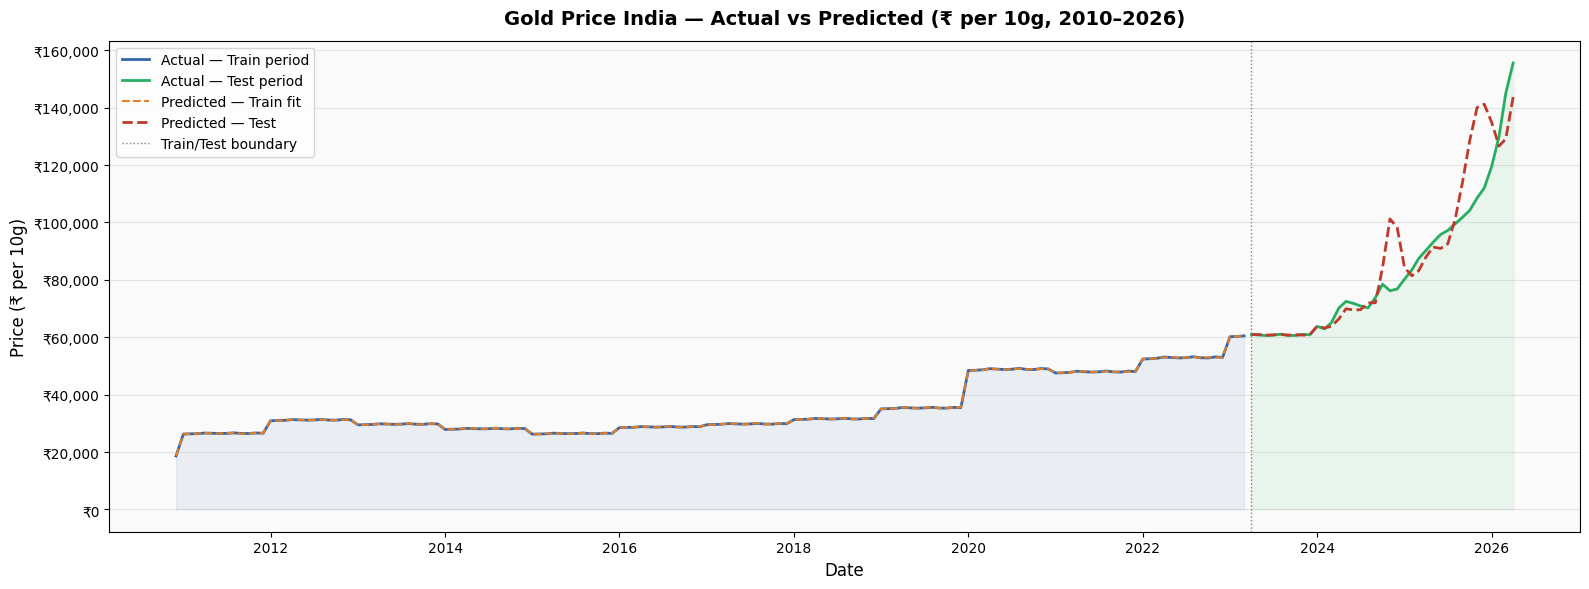

Saved: outputs/actual_vs_predicted_INR.png


In [10]:
train_pred = model.predict(X_train)

fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(train_df['Date'], train_df['Close'], alpha=0.08, color='#3266ad')
ax.fill_between(test_df['Date'],  test_df['Close'],  alpha=0.08, color='#27ae60')

ax.plot(train_df['Date'], train_df['Close'],  color='#3266ad', linewidth=2,   label='Actual — Train period')
ax.plot(test_df['Date'],  test_df['Close'],   color='#27ae60', linewidth=2,   label='Actual — Test period')
ax.plot(train_df['Date'], train_pred,          color='#e67e22', linewidth=1.5, linestyle='--', label='Predicted — Train fit')
ax.plot(test_df['Date'],  y_pred,              color='#c0392b', linewidth=2,   linestyle='--', label='Predicted — Test')

ax.axvline(x=test_df['Date'].iloc[0], color='gray', linewidth=1, linestyle=':', label='Train/Test boundary')

ax.set_title('Gold Price India — Actual vs Predicted (₹ per 10g, 2010–2026)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (₹ per 10g)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('outputs/actual_vs_predicted_INR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/actual_vs_predicted_INR.png')

## Step 8 — Residuals (Error Analysis)

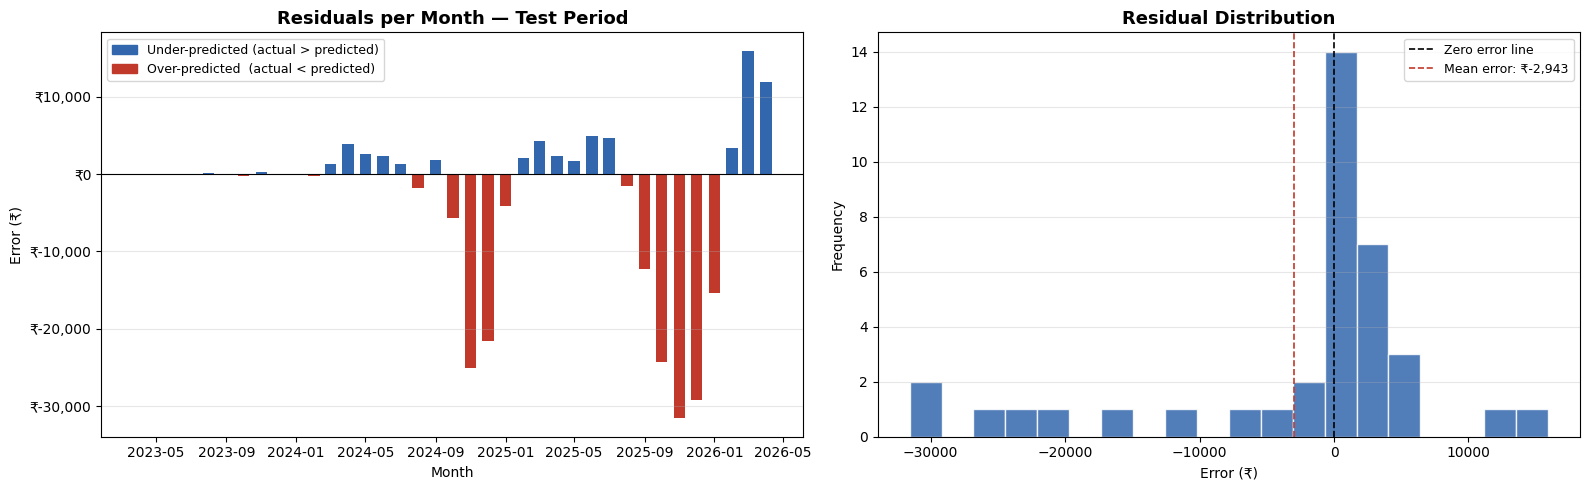

Saved: outputs/residuals_INR.png


In [11]:
residuals = y_true - y_pred
colors     = ['#3266ad' if r >= 0 else '#c0392b' for r in residuals]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — error per month
axes[0].bar(test_df['Date'], residuals, color=colors, width=20)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residuals per Month — Test Period', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Error (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[0].grid(axis='y', alpha=0.3)
blue_p = mpatches.Patch(color='#3266ad', label='Under-predicted (actual > predicted)')
red_p  = mpatches.Patch(color='#c0392b', label='Over-predicted  (actual < predicted)')
axes[0].legend(handles=[blue_p, red_p], fontsize=9)

# Histogram — distribution of errors
axes[1].hist(residuals, bins=20, color='#3266ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0,                   color='black',   linewidth=1.2, linestyle='--', label='Zero error line')
axes[1].axvline(np.mean(residuals),  color='#c0392b', linewidth=1.2, linestyle='--',
                label=f'Mean error: ₹{np.mean(residuals):,.0f}')
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Error (₹)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/residuals_INR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/residuals_INR.png')

## Step 9 — Future Forecast (Next 12 Months)

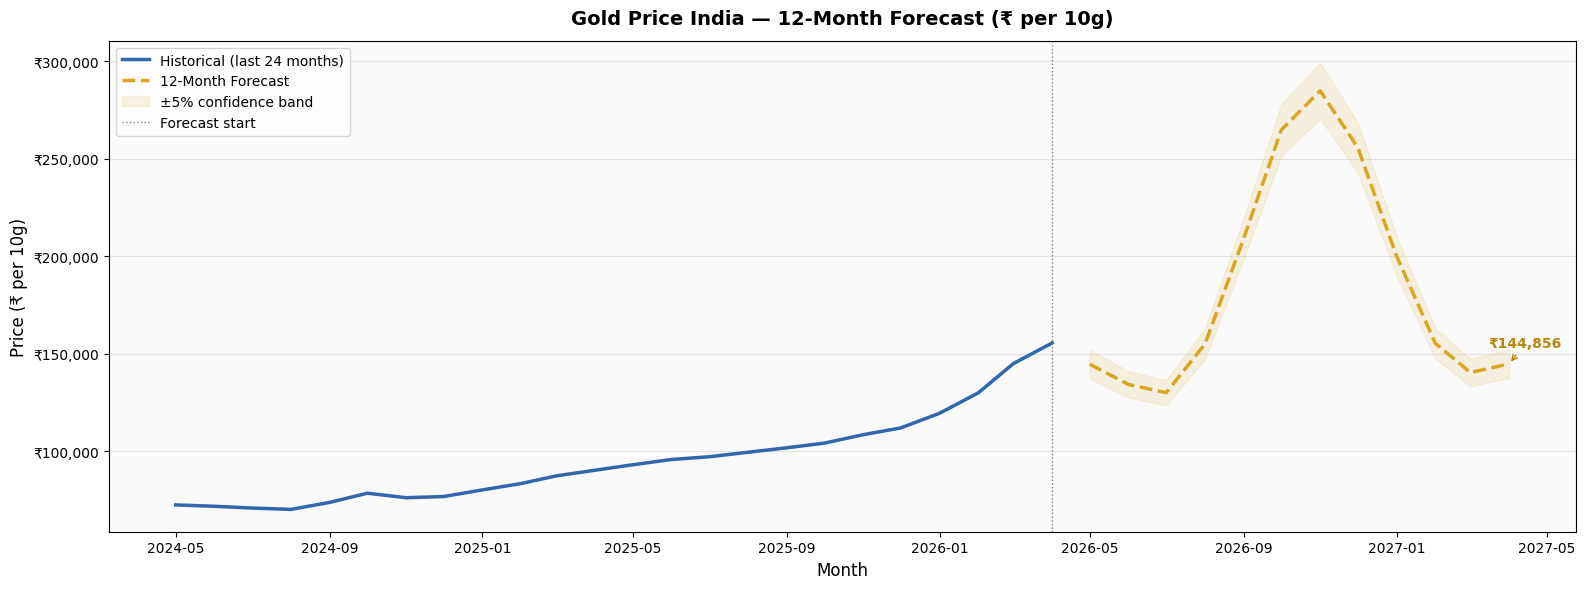

Saved: outputs/future_forecast_INR.png

       12-MONTH FORECAST SUMMARY (INR)
  Current price (Apr 2026)  : ₹   155,570
  May 2026                  : ₹   144,669
  Jun 2026                  : ₹   134,249
  Jul 2026                  : ₹   130,073
  Aug 2026                  : ₹   154,985
  Sep 2026                  : ₹   209,342
  Oct 2026                  : ₹   264,867
  Nov 2026                  : ₹   284,933
  Dec 2026                  : ₹   255,853
  Jan 2027                  : ₹   200,198
  Feb 2027                  : ₹   155,355
  Mar 2027                  : ₹   140,397
  Apr 2027                  : ₹   144,856

  Expected change (12 months): -6.89%


In [12]:
last_t    = df['t'].iloc[-1]
last_ma3  = df['Close'].iloc[-3:].mean()
last_ma6  = df['Close'].iloc[-6:].mean()
last_ma12 = df['Close'].iloc[-12:].mean()

future_rows = []
for i in range(1, 13):
    t = last_t + i
    future_rows.append({
        't':    t,
        't2':   t ** 2,
        'sin1': np.sin(2 * np.pi * t / 12),
        'cos1': np.cos(2 * np.pi * t / 12),
        'sin2': np.sin(4 * np.pi * t / 12),
        'cos2': np.cos(4 * np.pi * t / 12),
        'ma3':  last_ma3,
        'ma6':  last_ma6,
        'ma12': last_ma12
    })

future_df   = pd.DataFrame(future_rows)
future_pred = model.predict(future_df)
last_date   = df['Date'].iloc[-1]
future_dates= pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Plot last 24 months + forecast
history = df.iloc[-24:]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(history['Date'],  history['Close'],  color='#3266ad', linewidth=2.5, label='Historical (last 24 months)')
ax.plot(future_dates,     future_pred,        color='#DAA520', linewidth=2.5, linestyle='--', label='12-Month Forecast')
ax.fill_between(future_dates,
                future_pred * 0.95,
                future_pred * 1.05,
                color='#DAA520', alpha=0.12, label='±5% confidence band')
ax.axvline(x=last_date, color='gray', linewidth=1, linestyle=':', label='Forecast start')

# Annotate forecast end point
ax.annotate(f'₹{future_pred[-1]:,.0f}',
            xy=(future_dates[-1], future_pred[-1]),
            xytext=(-15, 12), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#B8860B',
            arrowprops=dict(arrowstyle='->', color='#B8860B', lw=1))

ax.set_title('Gold Price India — 12-Month Forecast (₹ per 10g)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Price (₹ per 10g)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('outputs/future_forecast_INR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/future_forecast_INR.png')

print()
print('=' * 52)
print('       12-MONTH FORECAST SUMMARY (INR)')
print('=' * 52)
print(f'  Current price (Apr 2026)  : ₹{df["Close"].iloc[-1]:>10,.0f}')
for i, (dt, pr) in enumerate(zip(future_dates, future_pred)):
    print(f'  {dt.strftime("%b %Y")}                  : ₹{pr:>10,.0f}')
change = ((future_pred[-1] - df['Close'].iloc[-1]) / df['Close'].iloc[-1]) * 100
print(f'\n  Expected change (12 months): {change:+.2f}%')
print('=' * 52)

## Step 10 — Final Project Summary

In [13]:
print('=' * 55)
print('   GOLD PRICE FORECASTING MODEL — INDIA (INR)')
print('           COMPLETE PROJECT SUMMARY')
print('=' * 55)
print(f'  Data source    : Yahoo Finance (GC=F) + BankBazaar')
print(f'  Currency       : Indian Rupee (₹) per 10 grams, 24K')
print(f'  Date range     : Jan 2010 → Apr 2026')
print(f'  Frequency      : Monthly')
print(f'  Total samples  : {len(df)}')
print(f'  Train / Test   : 80% / 20%')
print(f'  Model          : Polynomial Regression (degree=2)')
print(f'  No. of features: 9')
print()
print('  PERFORMANCE METRICS (Test Set):')
print(f'    MAE            : ₹{mae:,.0f}')
print(f'    RMSE           : ₹{rmse:,.0f}')
print(f'    MAPE           : {mape:.2f}%')
print(f'    R² (train)     : {model.score(X_train, y_train):.4f}')
print(f'    R² (test)      : {r2_test:.4f}')
print()
print('  OUTPUT FILES SAVED:')
print('    outputs/raw_gold_inr.png')
print('    outputs/actual_vs_predicted_INR.png')
print('    outputs/residuals_INR.png')
print('    outputs/future_forecast_INR.png')
print('    models/gold_inr_model.pkl')
print('    data/gold_inr_data.csv')
print('=' * 55)

   GOLD PRICE FORECASTING MODEL — INDIA (INR)
           COMPLETE PROJECT SUMMARY
  Data source    : Yahoo Finance (GC=F) + BankBazaar
  Currency       : Indian Rupee (₹) per 10 grams, 24K
  Date range     : Jan 2010 → Apr 2026
  Frequency      : Monthly
  Total samples  : 185
  Train / Test   : 80% / 20%
  Model          : Polynomial Regression (degree=2)
  No. of features: 9

  PERFORMANCE METRICS (Test Set):
    MAE            : ₹6,430
    RMSE           : ₹11,009
    MAPE           : 6.60%
    R² (train)     : 1.0000
    R² (test)      : 0.7977

  OUTPUT FILES SAVED:
    outputs/raw_gold_inr.png
    outputs/actual_vs_predicted_INR.png
    outputs/residuals_INR.png
    outputs/future_forecast_INR.png
    models/gold_inr_model.pkl
    data/gold_inr_data.csv


In [16]:
import shutil, os, glob

# Clean up old failed zip attempt first
if os.path.exists('my_gold_project'):
    shutil.rmtree('my_gold_project')

# Create fresh clean folders
os.makedirs('my_gold_project/outputs', exist_ok=True)
os.makedirs('my_gold_project/data',    exist_ok=True)
os.makedirs('my_gold_project/models',  exist_ok=True)

# Copy only your project files
for f in glob.glob('outputs/*.png'):
    shutil.copy(f, 'my_gold_project/outputs/')

shutil.copy('data/gold_inr_data.csv',    'my_gold_project/data/')
shutil.copy('models/gold_inr_model.pkl', 'my_gold_project/models/')

# Zip it
shutil.make_archive('my_gold_project', 'zip', '.', 'my_gold_project')

# Confirm what's inside
print("✅ Zip created. Contents:")
import zipfile
with zipfile.ZipFile('my_gold_project.zip', 'r') as z:
    for name in z.namelist():
        print(" ", name)

✅ Zip created. Contents:
  my_gold_project/
  my_gold_project/data/
  my_gold_project/models/
  my_gold_project/outputs/
  my_gold_project/models/gold_inr_model.pkl
  my_gold_project/data/gold_inr_data.csv
  my_gold_project/outputs/future_forecast_INR.png
  my_gold_project/outputs/actual_vs_predicted_INR.png
  my_gold_project/outputs/raw_gold_inr.png
  my_gold_project/outputs/residuals_INR.png
